In [1]:
from solver_selection_thm.physics import ModelTHM, initialize, run, params
from solver_selection_thm.selector import SolverSelector
from solver_selection_thm.solver_space import CategoricalChoices, NumericalChoices
from solver_selection_thm.performance_predictor import (
    PerformancePredictorPassiveAgressive,
    PerformancePredictorEpsGreedy,
    RewardEstimator,
)
from solver_selection_thm.solver_space import SolverSpace
from solver_selection_thm.pp_binding import (
    KNOWN_SOLVER_COMPONENTS_THM,
    SolverSelectionMixinTHM,
)
from thm_runscript import make_solver_space_scheme_fthm
import numpy as np
from matplotlib import pyplot as plt

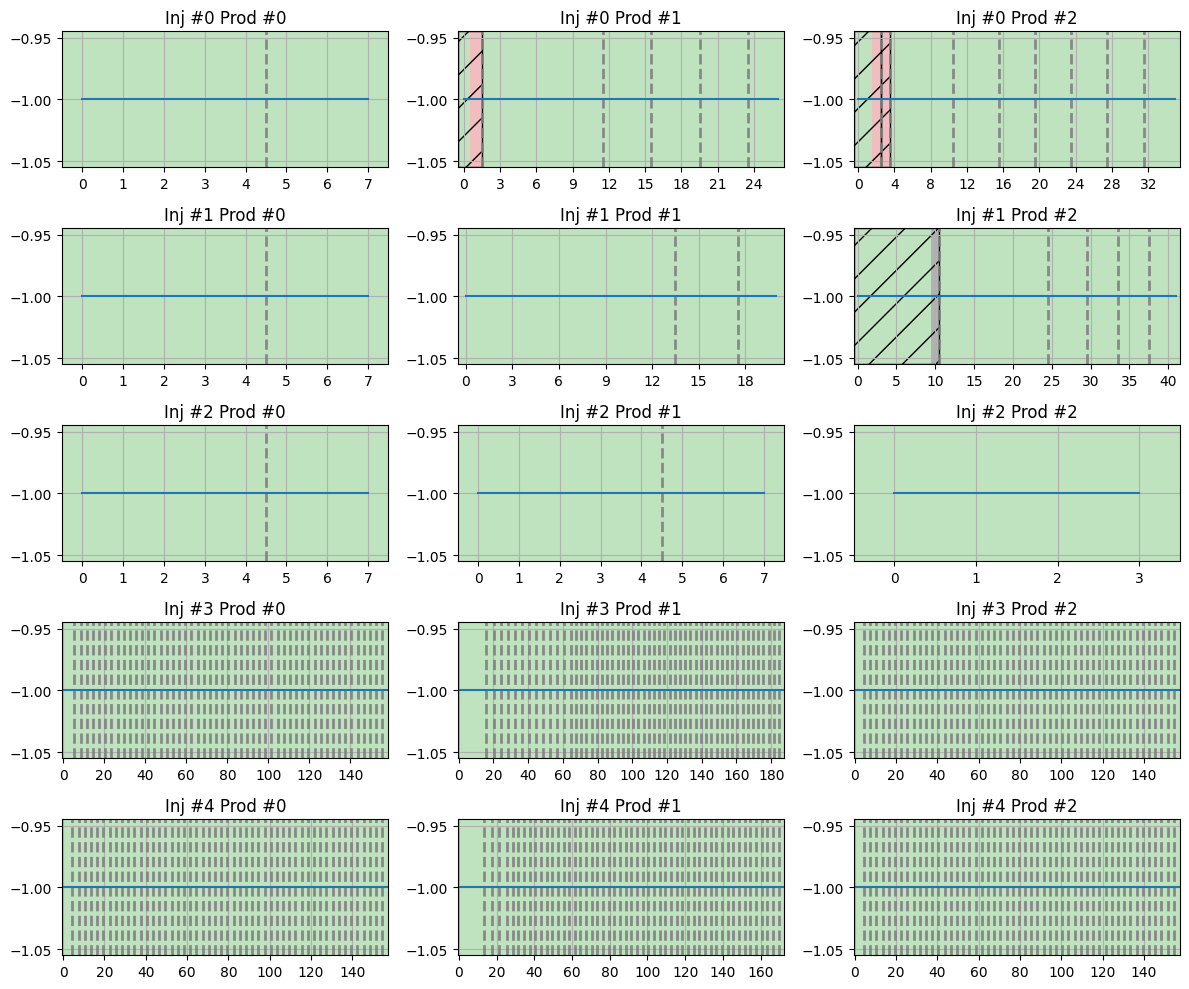

In [8]:
from itertools import count
from plot_utils import (
    color_converged_reason,
    color_time_steps,
    get_gmres_iterations,
    load_data,
    get_cfl,
    get_enthalpy_max,
    get_peclet_max,
    get_temp_max,
    get_temp_min,
    get_num_sticking_sliding_open,
    get_linear_solve_time
)
from solver_selection_thm.spe_physics import X_SLICES, Z_SLICES, simulation_name, params


data_simulations = []

for z_slice in Z_SLICES:
    data_row = []
    data_simulations.append(data_row)
    for x_slice in X_SLICES:
        params["x_slice"] = x_slice
        params["z_slice"] = z_slice
        sim_name = simulation_name(params)
        try:
            data = load_data(f"../stats/{sim_name}.json")
            data_row.append(data)
        except FileNotFoundError:
            data_row.append(None)


fig, axes = plt.subplots(
    nrows=len(Z_SLICES), ncols=len(X_SLICES), figsize=(12, 10)
)
for i, data_row in enumerate(data_simulations):
    for j, data in enumerate(data_row):
        if data == None:
            continue
        ax = axes[i][j]
        plt.sca(ax)

        color_converged_reason(data)
        color_time_steps(data)

        ax.plot(get_linear_solve_time(data))
        # ax.set_yscale('log')
        # print(inlet_placement, outlet_placement)
        ax.set_title(f"Inj #{i} Prod #{j}")

plt.tight_layout()